In [1]:
import numpy as np
from pathlib import Path
from typing import Dict, List

from model_ranking import (
    load_h5,
    get_NA_prediction_path,
    MODEL_ABBREVIATIONS_TO_DATASET,
    find_batchnorm_pred_path,
    plot_model_performance_separate_figures
)

from pytorch3dunet.unet3d.config import load_config_direct #pyright: ignore[reportUnknownVariableType]

INFO: P [MainThread] 2025-09-17 11:44:46,719 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [7]:
models: Dict[str, List[str]] = {
    "EtoE": [
        "EtoE_model5",
        "EtoE_model_NA2",
        "EtoE_model_Res1",
        #"EtoE_model_Unetr2",
    ],
    "HtoE": [
        "HmtoE_model4",
        "HmtoE_model_NA2",
        "HmtoE_model_Res1",
        # "HmtoE_model_Unetr2",
    ],
    "RtoE": [
        "RmtoE_model4",
        "RmtoE_model_NA2",
        "RmtoE_model_Res1",
        #"RmtoE_model_Unetr2",
    ],
    "VtoE": [
        "VtoE_model2",
        "VtoE_model_NA2",
        "VtoE_model_Res1",
    ],
    "EtoH": [
        "EtoHm_model5",
        "EtoHm_model_NA2",
        "EtoHm_model_Res1",
        #"EtoHm_model_Unetr2",
    ],
    "HtoH": [
        "HmtoHm_model4",
        "HmtoHm_model_NA2",
        "HmtoHm_model_Res1",
        # "HmtoHm_model_Unetr2",
    ],
    "RtoH": [
        "RmtoHm_model4",
        "RmtoHm_model_NA2",
        "RmtoHm_model_Res1",
        #"RmtoHm_model_Unetr2",
    ],
    "VtoH": [
        "VtoHm_model2",
        "VtoHm_model_NA2",
        "VtoHm_model_Res1",
    ],
    "EtoR": [
        "EtoRm_model5",
        "EtoRm_model_NA2",
        "EtoRm_model_Res1",
        #"EtoRm_model_Unetr2",
    ],
    "HtoR": [
        "HmtoRm_model4",
        "HmtoRm_model_NA2",
        "HmtoRm_model_Res1",
        #"HmtoRm_model_Unetr2",
    ],
    "RtoR": [
        "RmtoRm_model4",
        "RmtoRm_model_NA2",
        "RmtoRm_model_Res1",
        #"RmtoRm_model_Unetr2",
    ],
    "VtoR": [
        "VtoRm_model2",
        "VtoRm_model_NA2",
        "VtoRm_model_Res1",
    ],
    "EtoV": [
        "EtoV_model5",
        "EtoV_model_NA2",
        "EtoV_model_Res1",
        #"EtoV_model_Unetr2",
    ],
    "HtoV": [
        "HmtoV_model4",
        "HmtoV_model_NA2",
        "HmtoV_model_Res1",
        # "HmtoV_model_Unetr2",
    ],
    "RtoV": [
        "RmtoV_model4",
        "RmtoV_model_NA2",
        "RmtoV_model_Res1",
        #"RmtoV_model_Unetr2",
    ],
}

In [8]:
base_path = Path("/g/kreshuk/talks/model_ranking_results/AdaptiveBatchNorm/Mitochondria")
base_transfer_path = "/scratch/talks/consistency_results/patch_segmentation/mitochondria"
run_approach= "consistency"
run_id = "P_full"
adabn_modes = ["train_mode_stats", "eval_mode_stats", "sequential_adabn"]

In [9]:
#per_target_perf_results: Dict[str, Dict[str, Dict[str,float]]] = {}
per_target_perf_results: Dict[str, Dict[str, Dict[str,float]]] = {}
for transfer, model_list in models.items():
    print(f"Transfer: {transfer}")
    target = MODEL_ABBREVIATIONS_TO_DATASET[transfer[-1]]
    if target not in per_target_perf_results:
        per_target_perf_results[target] = {}
    transfer_gap = f"{MODEL_ABBREVIATIONS_TO_DATASET[transfer[0]]}_to_{target}_gap"
    for i, model_name in enumerate(model_list):
        eval_scores: Dict[str, float] = {}
        for adbn_mode in adabn_modes:
            adabn_base_path = base_path / adbn_mode
            pred_path = find_batchnorm_pred_path(model_name, adabn_base_path, perturbation="none", return_summary=True)
            median_eval_score_adjusted = load_h5(pred_path, "F1_eval_median")[1]
            eval_scores[adbn_mode] = median_eval_score_adjusted

        yaml_paths = list((pred_path.parent.parent.parent.parent / "checkpoints").glob("*.yaml"))
        assert len(yaml_paths) == 1, f"Expected one YAML file for {model_name}, found {len(yaml_paths)}"
        yaml_path = yaml_paths[0]
        initial_model_name = Path(load_config_direct(yaml_path)[0]["model_cfg"]["source_checkpoint"]).parent.stem
        initial_pred_path = get_NA_prediction_path(
            model_name=initial_model_name,
            target=target,
            base_path=base_transfer_path,
            approach=run_approach,
            run_id=run_id,
        )
        eval_score_direct = load_h5(initial_pred_path, "hard_f1")
        median_eval_score = np.median(eval_score_direct, axis=0)[1]

        eval_scores["direct"] = median_eval_score

        per_target_perf_results[target].update({
            model_name : eval_scores
        })


Transfer: EtoE
Transfer: HtoE
Transfer: HtoE
Transfer: RtoE
Transfer: RtoE
Transfer: VtoE
Transfer: VtoE
Transfer: EtoH
Transfer: EtoH
Transfer: HtoH
Transfer: HtoH
Transfer: RtoH
Transfer: RtoH
Transfer: VtoH
Transfer: VtoH
Transfer: EtoR
Transfer: EtoR
Transfer: HtoR
Transfer: HtoR
Transfer: RtoR
Transfer: RtoR
Transfer: VtoR
Transfer: VtoR
Transfer: EtoV
Transfer: EtoV
Transfer: HtoV
Transfer: HtoV
Transfer: RtoV
Transfer: RtoV


In [10]:
per_target_perf_results

{'EPFL': {'EtoE_model5': {'train_mode_stats': 0.94779384,
   'eval_mode_stats': 0.0022884319,
   'sequential_adabn': 0.9478164,
   'direct': 0.9456775},
  'EtoE_model_NA2': {'train_mode_stats': 0.93458736,
   'eval_mode_stats': 0.002376256,
   'sequential_adabn': 0.9351778,
   'direct': 0.8867508},
  'EtoE_model_Res1': {'train_mode_stats': 0.9431113,
   'eval_mode_stats': 0.8006618,
   'sequential_adabn': 0.94339275,
   'direct': 0.9407506},
  'HmtoE_model4': {'train_mode_stats': 0.8921592,
   'eval_mode_stats': 0.0,
   'sequential_adabn': 0.8928444,
   'direct': 0.7714988},
  'HmtoE_model_NA2': {'train_mode_stats': 0.89170885,
   'eval_mode_stats': 0.101946235,
   'sequential_adabn': 0.8924315,
   'direct': 0.6937871},
  'HmtoE_model_Res1': {'train_mode_stats': 0.9143721,
   'eval_mode_stats': 0.1081703,
   'sequential_adabn': 0.9145335,
   'direct': 0.8338802},
  'RmtoE_model4': {'train_mode_stats': 0.85881746,
   'eval_mode_stats': 0.0,
   'sequential_adabn': 0.86041063,
   'direct'

Creating separate plots for each target...


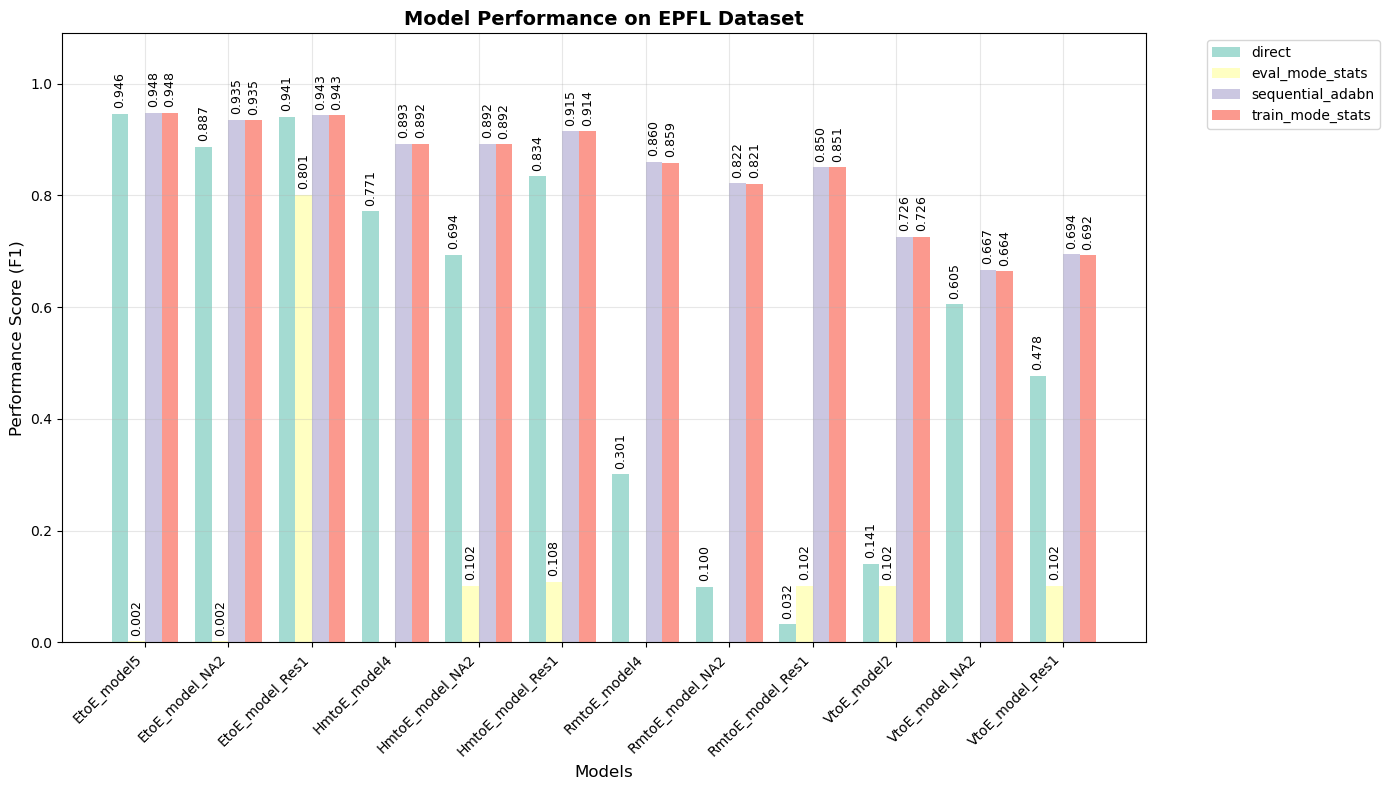

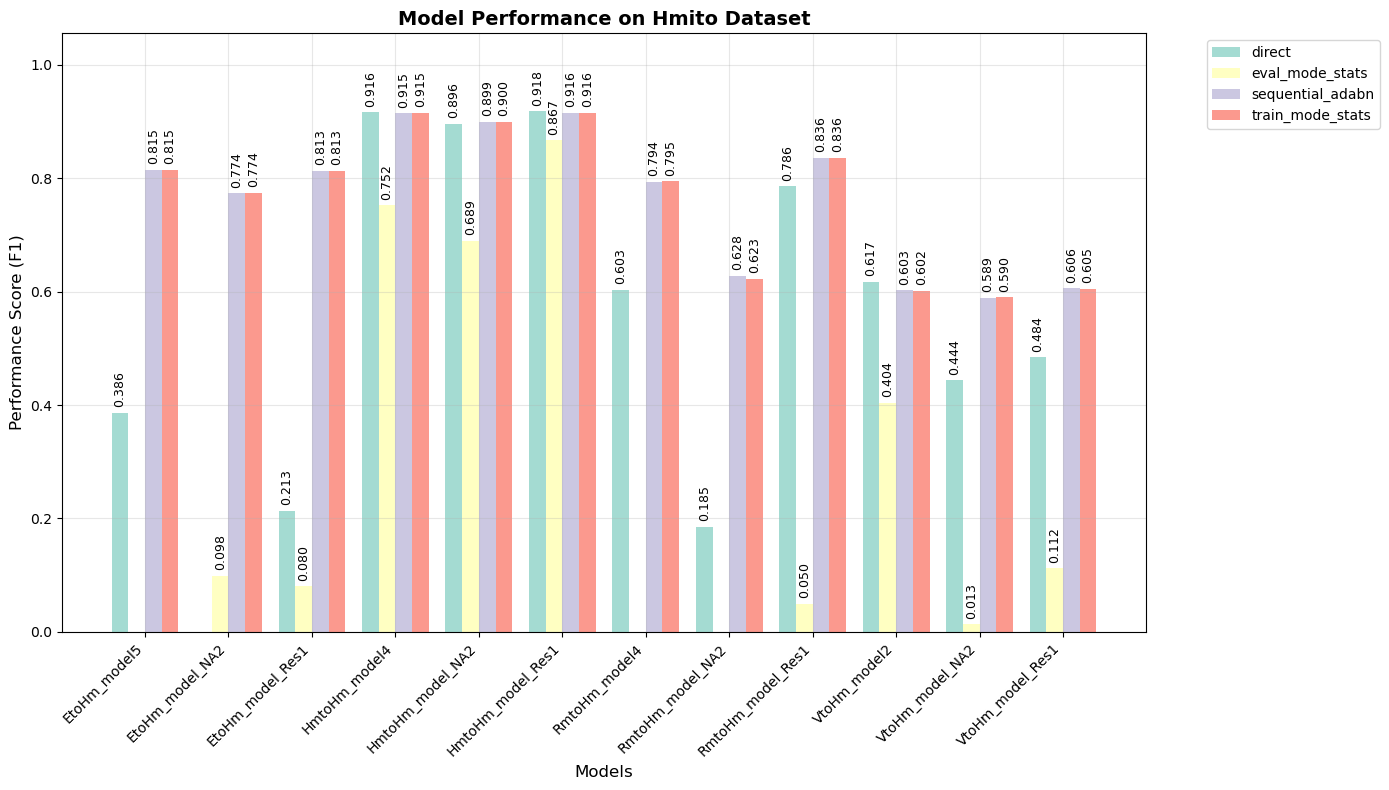

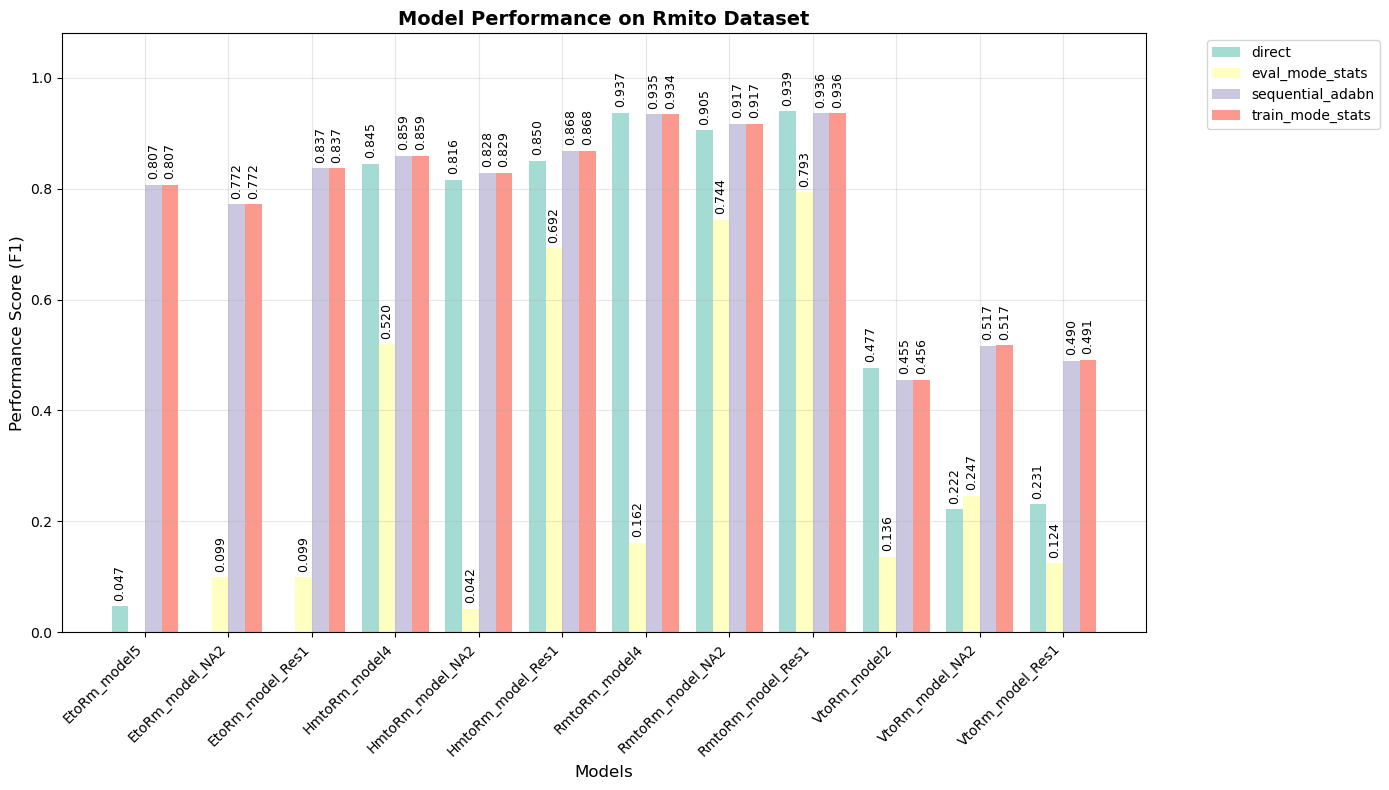

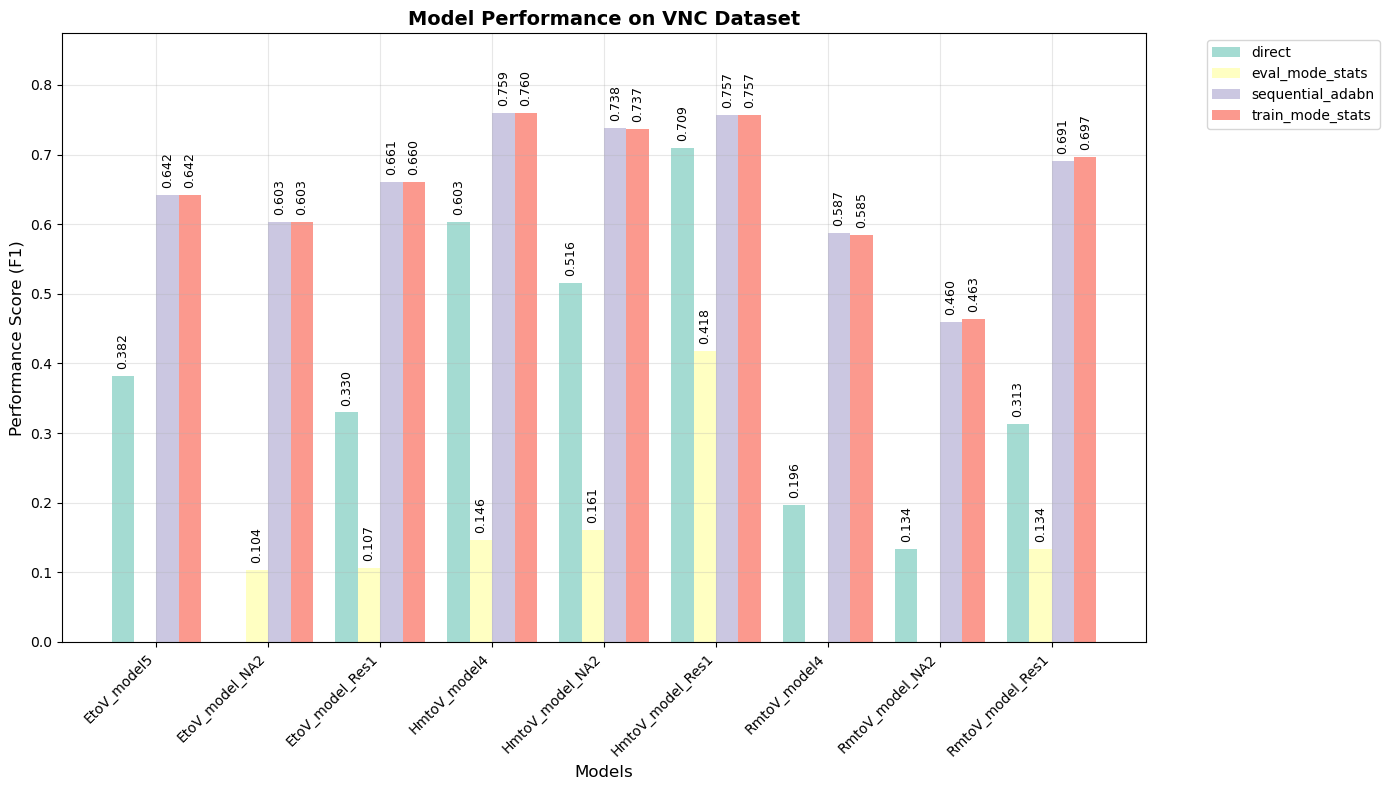

In [11]:
# Example usage - Plot each target in separate figures
print("Creating separate plots for each target...")
plot_model_performance_separate_figures(per_target_perf_results, save_plots=False)